The goal of this notebook is to explore the implementation of boundary conditions in NGSolve with respect to the Prolongation matrix, the inverse function, and the Projector function.

In [1]:
# import necessary packages
from ngsolve import *
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import norm,inv
import time

In [2]:
coarse_mesh = Mesh(unit_square.GenerateMesh(maxh=1/16))
fesc = H1(coarse_mesh, order=1, dirichlet="left|right")
fine_mesh = Mesh(coarse_mesh.ngmesh.Copy())
fesf = H1(fine_mesh, order=1, dirichlet="left|right")
fesf.mesh.Refine()
P = fesf.Prolongation().CreateMatrix(fesf.mesh.levels-1)
PT = P.CreateTranspose()


In [3]:
coarse_mesh2 = Mesh(unit_square.GenerateMesh(maxh=1/16))
fesc2 = H1(coarse_mesh2, order=1)
fine_mesh2 = Mesh(coarse_mesh2.ngmesh.Copy())
fesf2 = H1(fine_mesh2, order=1)
fesf2.mesh.Refine()
P2 = fesf2.Prolongation().CreateMatrix(fesf2.mesh.levels-1)
PT2 = P2.CreateTranspose()
#print("free dofs of fesc2 without \"dirichlet\" flag:\n",fesc2.FreeDofs())
#print("free dofs of fesf2 without \"dirichlet\" flag:\n", fesf2.FreeDofs())
#print("dofs of fesf2fine:\n",fesf2.GetNDofLevel(1))
#print("dofs of fesf2 lower level (coarse):\n",fesf2.GetNDofLevel(0))

In [4]:
# help(Draw)

In [ ]:
u, v = fesf.TnT()
a = BilinearForm(grad(u)*grad(v)*dx).Assemble()
f = LinearForm(v*dx).Assemble()
a_fine = a.GetMatrixLevel()
#print(a_fine)

Row 0:   0: 1   339: -4.17957e-15   730: -0.5   1211: -0.5
Row 1:   1: 0.851839   361: -0.243593   751: -0.304714   753: -0.303532
Row 2:   2: 1   376: 0   782: -0.5   1218: -0.5
Row 3:   3: 0.82844   396: -0.413508   805: -0.205344   807: -0.209588
Row 4:   4: 2.05806   339: -0.15937   340: 0.161458   730: -0.5   731: -0.685102   832: -0.875045
Row 5:   5: 2.33332   340: -0.198708   341: 0.454755   731: -0.523643   732: -0.791008   733: -1.27472
Row 6:   6: 1.74449   341: -0.464606   342: -0.279878   732: -0.336252   734: -0.663759
Row 7:   7: 2.26331   342: -0.279878   343: -0.266442   344: 0.530118   735: -1.14298   1212: -1.10413
Row 8:   8: 2.27262   343: -0.266442   345: -0.266451   346: 0.539247   736: -1.14059   1213: -1.13838
Row 9:   9: 2.27741   345: -0.266451   347: -0.266888   348: 0.543966   737: -1.15374   1214: -1.1343
Row 10:   10: 2.27887   347: -0.266888   349: -0.265022   350: 0.544867   738: -1.17057   1215: -1.12125
Row 11:   11: 2.27561   349: -0.265022   351: -0

In [6]:

m = a_fine.CreateSmoother(fesf.FreeDofs(), GS=True)
x0 = CoefficientFunction(sin(pi*x)*sin(pi*y)+(1/10)*sin(10*pi*x)*sin(10*pi*y))
xi = GridFunction(fesf)
xi.Set(x0)
yi = GridFunction(fesf)
s = Draw(xi,fine_mesh,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})
smootha = a_fine
for i in range(20):
    smootha = m @ smootha
    smootha.Mult(xi.vec, yi.vec.data)
    xi.vec.data -= yi.vec
    #time.sleep(1)
    s.Redraw()
# yi.vec.data = a.mat * xi.vec
rfine = GridFunction(fesf)
rfine.Set(1, BND)
rfine.vec.data = - a.mat * xi.vec

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'transformations'…

In [7]:
phi, nu = fesc.TnT()
a_coarse = BilinearForm(grad(phi)*grad(nu)*dx).Assemble()
print("Checking A coarse\n")
#print(a_coarse.mat)



alt_coarse = PT @ a_fine @ P
#print(alt_coarse)
ac_diff = a_coarse.mat - alt_coarse
# print(ac_diff)
type(a_coarse.mat), type(alt_coarse)

Checking A coarse



(ngsolve.la.SparseMatrixd, ngsolve.la.SparseMatrixd)

The difference between the two versions of A coarse is 4.256330869013341e-14


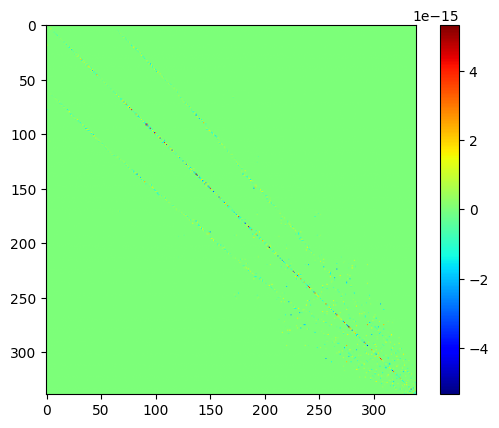

In [8]:
rows1, cols1, vals1 = a_coarse.mat.COO()
rows2, cols2, vals2 = alt_coarse.COO()

ac1 = sp.csr_matrix((vals1,(rows1,cols1)))
ac2 = sp.csr_matrix((vals2,(rows2,cols2)))
acdiff = ac1 - ac2
print("The difference between the two versions of A coarse is", norm(acdiff))
plt.imshow(acdiff.toarray(), cmap='jet')
plt.colorbar()
plt.show()


In [14]:
rcoarse = PT * rfine.vec
xcoarse = GridFunction(fesc)
xcoarse.Set(1, BND)
xcoarse.vec.data += a_coarse.mat.Inverse(freedofs=fesc.FreeDofs()) * rcoarse
# acinv = a_coarse.mat.Inverse(freedofs=fesc.FreeDofs())
# icoarse = acinv @ a_coarse.mat
# # accsc = sp.csc_matrix(ac1)
# # ainv = inv(accsc)
# # print(ainv)
# print(xcoarse.vec)
Draw(xcoarse,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'transformations'…

BaseWebGuiScene

In [ ]:
# yc = GridFunction(fesc)
# yc.vec.data = PT * xi.vec # this supposes that the result of the GS smoothing is a vector yi of the "fine" length
# Draw(yc,coarse_mesh, settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})


In [ ]:
# xc = GridFunction(fesc)
# #print(xc.vec)
# xc.vec.data = - acinv * yc.vec
# #print(xc.vec)
# Draw(xc,coarse_mesh, settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})

In [ ]:
# ef = GridFunction(fesf)
# ef.vec.data = P * ec.vec
# # len(ef.vec)

In [19]:
erfine = GridFunction(fesf)
erfine.Set(1,BND)
erfine.vec.data = P * xcoarse.vec

er1 = erfine.vec.Norm()
print("Error after 1 cycle", er1)
Draw(erfine,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})

Error after 1 cycle 19.249376207966495


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'transformations'…

BaseWebGuiScene

In [20]:
xnext = xi.vec + erfine.vec